# Notebook


## 1. Setup

In [1]:
import sys
import json
import shutil
from pathlib import Path

# Racine du projet : remonte depuis cwd jusqu'a trouver run_pipeline.py
# (robuste a jupyter lance depuis project/ ou un autre sous-dossier)
def _find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "run_pipeline.py").exists():
            return p
    return start

ROOT = _find_root(Path.cwd())
RUNS_DIR = ROOT / "runs"

for _p in (ROOT, ROOT / "project", ROOT / "project" / "export",
           ROOT / "yolo", ROOT / "yolo" / "eval"):
    p = str(_p)
    if p not in sys.path:
        sys.path.insert(0, p)

# Reutilise les helpers du pipeline
from runs import find_runs, list_images, pick_image_source

print(f"ROOT     = {ROOT}")
print(f"RUNS_DIR = {RUNS_DIR}  (exists={RUNS_DIR.exists()})")

ROOT     = c:\Users\Sr-Sh\Desktop\LARD-LAAS-TAF
RUNS_DIR = c:\Users\Sr-Sh\Desktop\LARD-LAAS-TAF\runs  (exists=True)


## 2. Generate (Phase 1 — TAF seul, offline)

Equivalent CLI : `py run_pipeline.py generate -n N`

Sample N scenarios via TAF/z3 et ecrit `runs/<ICAO_RWY>/` avec `.yaml`,
`poses_cam_export.json`, `fault_profile.json`, `weather_profile.json`.
Pas besoin de X-Plane. `nb_scenarios=None` => valeur de `project/settings.xml`.

In [2]:
from Generate import generate_runs

# generate_runs(nb_scenarios=5, quiet=False)
generate_runs(nb_scenarios=1, quiet=False);

 PHASE 1 : Generation TAF
[Generate] Template : templates/base_template.xml
[Generate] Sortie   : ../output/
[Generate] Scenarios: 1

parsing template: templates/base_template.xml
Current path: ../output/scenario_0/
Miscellaneous::file_check() -> "../output/scenario_0/scenario_0.xml" does not exist
Create new test case: scenario.xml
--------------------------------------------------------------------------------
additional contraint(s): 
['var_123_0 == 280.0', 'var_128_0 == 1159.56095', 'var_122_0 == 2000.0']
--------------------------------------------------------------------------------
--------------------------------------------------------------------------------
additional contraint(s): 
['var_99_0 == 100.0', 'var_93_0 == 100.0', 'var_104_0 == 0.0', 'var_44_0 == 0.0', 'var_105_0 == 100.0', 'var_35_0 == 0.0', 'var_57_0 == 0', 'var_55_0 == 2', 'var_60_0 == 100.0', 'var_42_0 == 100.0', 'var_107_0 == 0.0', 'var_33_0 == 100.0', 'var_39_0 == 100.0', 'var_69_0 == 100.0', 'var_101_0 == 0

## 3. Render (Phase 2 — Rendu X-Plane + fautes capteur)

Equivalent CLI :
- `py run_pipeline.py render LFPO_24 --xplane-dir "C:/X-Plane 12"`
- `py run_pipeline.py render --all --xplane-dir "C:/X-Plane 12"`

Suppose que la Phase 1 (`generate`) a deja ete faite. Necessite X-Plane 12
lance (mode fenetre, scaling 100%). Sortie : `footage/`, `degraded/`.
Le GT LARD n'est PAS genere ici (il l'est en Phase 3, juste avant l'IoU).

In [3]:
from runs import render_runs

XPLANE_DIR = r"C:/X-Plane 12"

# Un seul run :
# render_runs(run_name="LFPO_24", xplane_dir=XPLANE_DIR)

# Tous les runs :
render_runs(all_runs=True, xplane_dir=XPLANE_DIR);

 PHASE 2 : Rendu X-Plane + fautes capteur

[Pipeline] 1 run(s) a rendre

--------------------------------------------------
 Run : KPDX_10L
--------------------------------------------------

  [Image] Rendu + fautes + GT pour KPDX_10L

  [XPLANE] Rendu de KPDX_10L...
  [XPLANE] Rendu de KPDX_10L (231 frames)...
  [XPLANE] Connexion UDP -> 127.0.0.1:49000
  [XPLANE] Fenetre resizee -> 1024x1024
  [XPLANE] Fenetre trouvee: 'X-Plane' rect=(237, 56, 1533, 1119)
  [XPLANE] Client rect: left=245 top=87 right=1525 bottom=1111
  [XPLANE] Desktop virtuel: {'left': 0, 'top': 0, 'width': 4480, 'height': 1440}
  [XPLANE] Capture : 1280x1024
  [XPLANE] Fenetre reelle: 1280x1024, fact=1.25x1.00
  [XPLANE] FOV programme: H=71.6° V=60.0° (readback: H=71.6° V=60.0°)
  [XPLANE] Plugin XPPython3 weather OK
  [WEATHER] Injecte : precip=0.66, clouds=Cumulonimbus(100%), vis=27647m, heure=14h local -> 20.5h UTC, avion_max=132m, nuages=1793-7793m MSL
  [WEATHER] Chargement textures + stabilisation nuages 5.0

## 4. Evaluate (Phase 3 — GT LARD + YOLO + IoU, sans X-Plane)

Equivalent CLI :
- `py run_pipeline.py evaluate LFPO_24`
- `py run_pipeline.py evaluate --all`

Suppose que `footage/` ou `degraded/` existe deja (Phase 2 faite). Genere
le GT LARD a la volee (`*_labels.csv`), puis YOLO predict + IoU. Re-executable
a volonte avec d'autres poids/seuils sans re-rendre.

In [4]:
from runs import evaluate_runs

# Un seul run :
# evaluate_runs(run_name="LFPO_24")

# Tous les runs :
evaluate_runs(all_runs=True);

 PHASE 3 : GT LARD + Detection YOLO + IoU

[Pipeline] 1 run(s) a evaluer

--------------------------------------------------
 Run : KPDX_10L
--------------------------------------------------

  [Eval] Detection + IoU pour KPDX_10L

  [YOLO] Prediction sur 231 images depuis footage/ (KPDX_10L)...
Prediction sur 231 images avec yolov8nTest.pt

image 1/231 C:\Users\Sr-Sh\Desktop\LARD-LAAS-TAF\runs\KPDX_10L\footage\KPDX_10L_000.jpg: 512x512 1 runway, 7.0ms
image 2/231 C:\Users\Sr-Sh\Desktop\LARD-LAAS-TAF\runs\KPDX_10L\footage\KPDX_10L_001.jpg: 512x512 1 runway, 7.9ms
image 3/231 C:\Users\Sr-Sh\Desktop\LARD-LAAS-TAF\runs\KPDX_10L\footage\KPDX_10L_002.jpg: 512x512 1 runway, 13.3ms
image 4/231 C:\Users\Sr-Sh\Desktop\LARD-LAAS-TAF\runs\KPDX_10L\footage\KPDX_10L_003.jpg: 512x512 1 runway, 10.2ms
image 5/231 C:\Users\Sr-Sh\Desktop\LARD-LAAS-TAF\runs\KPDX_10L\footage\KPDX_10L_004.jpg: 512x512 1 runway, 12.5ms
image 6/231 C:\Users\Sr-Sh\Desktop\LARD-LAAS-TAF\runs\KPDX_10L\footage\KPDX_10L_005.jpg

## 5. Lister les runs disponibles

In [5]:
runs = find_runs(all_runs=True)
for r in runs:
    print(f"  - {r.name}")
print(f"\n{len(runs)} run(s) trouve(s).")

  - KPDX_10L

1 run(s) trouve(s).


## 6. Création du dataset (Regroupement des dossiers d'images)

In [2]:
import csv
from runway import runway_from_run_name

# Colonnes du metadata.csv (sous-ensemble du CSV LARD natif).
# Retire : original_dataset, slant_distance, height_above_runway, x_TR..y_BR.
# Ajoute : time_of_day (heure locale du scenario, lue dans weather_profile.json).
# Conventions appliquees ci-dessous (cf. LARD/src/labeling/label_export.py) :
#   - along_track_distance : LARD stocke en miles nautiques + valeur absolue
#                            -> on convertit en metres et on negate (avion AVANT le seuil).
#   - pitch                : LARD stocke 90 + pitch_reel (90 deg = horizontal)
#                            -> on soustrait 90.
#   - yaw                  : stocke en cap vrai (Nord, sens horaire) depuis le
#                            fix LTP/FPAP dans lard_bridge -> on wrap dans
#                            [-180, +180] sans offset.
META_COLS = [
    "height", "width", "scenario",
    "airport", "runway", "time", "time_of_day",
    "lat", "lon", "alt", "yaw", "pitch", "roll",
    "along_track_distance",
    "lateral_path_angle", "vertical_path_angle",
    "image",
]

LARD_TO_META = {"lat_cam": "lat", "lon_cam": "lon", "alt_cam": "alt"}


def _normalize_row(row: dict) -> dict:
    """Convertit les conventions LARD -> conventions standard (in-place)."""
    if row.get("along_track_distance"):
        miles = float(row["along_track_distance"])
        row["along_track_distance"] = f"{-miles * 1852.0:.6f}"
    if row.get("pitch"):
        row["pitch"] = f"{float(row['pitch']) - 90.0:.6f}"
    if row.get("yaw"):
        y = float(row["yaw"]) % 360.0
        if y > 180.0:
            y -= 360.0
        row["yaw"] = f"{y:.6f}"
    return row


def _load_lard_rows(run: Path, target_rwy: str) -> dict:
    """Charge le CSV LARD du run, filtre sur la piste cible, indexe par nom d'image."""
    csvs = list(run.glob("*_labels.csv"))
    if not csvs:
        return {}
    rows = {}
    with open(csvs[0], newline="") as f:
        for row in csv.DictReader(f, delimiter=";"):
            if row.get("runway") != target_rwy:
                continue
            rows[Path(row["image"]).name] = row
    return rows


def _load_time_of_day(run: Path) -> str:
    """Lit weather_profile.json et retourne time_of_day_h (str), '' si absent."""
    wp = run / "weather_profile.json"
    if not wp.exists():
        return ""
    try:
        data = json.loads(wp.read_text())
    except (json.JSONDecodeError, OSError):
        return ""
    return str(data.get("weather", {}).get("time_of_day_h", ""))


def build_dataset(out_dir: Path = RUNS_DIR / "dataset") -> dict:
    """Pour chaque run, copie les images de degraded/ (prio) ou footage/ vers out_dir/images/
    et ecrit out_dir/metadata.csv.
    """
    if out_dir.exists():
        shutil.rmtree(out_dir)
    img_dir = out_dir / "images"
    img_dir.mkdir(parents=True)

    summary = {}
    counter = 0
    meta_rows = []
    for run in find_runs(all_runs=True):
        src = pick_image_source(run)
        kind = src.name
        images = list_images(src)
        if not images:
            summary[run.name] = (kind, 0, "absent")
            continue

        target_rwy = runway_from_run_name(run.name)
        lard_rows = _load_lard_rows(run, target_rwy)
        time_of_day = _load_time_of_day(run)

        n = 0
        for img in images:
            new_name = f"{counter:06d}{img.suffix.lower()}"
            shutil.copy2(img, img_dir / new_name)

            row = {c: "" for c in META_COLS}
            lard = lard_rows.get(img.name, {})
            for k, v in lard.items():
                key = LARD_TO_META.get(k, k)
                if key in row:
                    row[key] = v
            row["image"] = f"images/{new_name}"
            row["scenario"] = row.get("scenario") or run.name
            row["time_of_day"] = time_of_day
            _normalize_row(row)
            meta_rows.append(row)

            counter += 1
            n += 1
        summary[run.name] = (kind, n, "ok")

    meta_path = out_dir / "metadata.csv"
    with open(meta_path, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=META_COLS)
        w.writeheader()
        w.writerows(meta_rows)

    total = sum(n for _, n, _ in summary.values())
    print(f"Dataset : {out_dir}")
    for name, (kind, n, status) in summary.items():
        print(f"  {name:<25} <- {kind:<8} ({n:>4} imgs) [{status}]")
    print(f"Total : {total} images")
    print(f"Metadata : {meta_path} ({len(meta_rows)} lignes)")
    return summary

build_dataset();

[SKIP] dataset : pas de .yaml
Dataset : c:\Users\Sr-Sh\Desktop\LARD-LAAS-TAF\runs\dataset
  KPDX_10L                  <- footage  ( 231 imgs) [ok]
Total : 231 images
Metadata : c:\Users\Sr-Sh\Desktop\LARD-LAAS-TAF\runs\dataset\metadata.csv (231 lignes)


## 7. Generer `yolo_box/` (images avec bbox YOLO dessinees)

Lit `predictions.csv` du run, dessine les bbox sur les images sources
(`degraded/` en priorite, sinon `footage/`) et ecrit dans `runs/<run>/yolo_box/`.

Usage :
- `build_yolo_box("LFPO_24")` : une seule run
- `build_yolo_box()`           : toutes les runs

In [7]:
from ultralytics import YOLO

def build_yolo_box(run_name: str | None = None,
                   line_width: int = 2, conf: float = 0.25, imgsz: int = 512):
    """Trace les bbox YOLO (trait fin) dans run_dir/yolo_box/. None = tous les runs.

    Meme appel que yolo/predict.py (model.predict + save=True), seul `line_width`
    est ajoute (non expose par predict()).
    """
    targets = find_runs(run_name=run_name, all_runs=run_name is None)
    model = YOLO(str(ROOT / "yolo" / "yolov8nTest.pt"))
    for run in targets:
        src = pick_image_source(run)
        out = run / "yolo_box"
        if out.exists():
            shutil.rmtree(out)
        model.predict(source=str(src), conf=conf, imgsz=imgsz, save=True,
                      line_width=line_width, project=str(run), name="yolo_box",
                      exist_ok=True, verbose=False)
        print(f"  {run.name} -> yolo_box/")

build_yolo_box()

[SKIP] dataset : pas de .yaml
Results saved to C:\Users\Sr-Sh\Desktop\LARD-LAAS-TAF\runs\KPDX_10L\yolo_box
  KPDX_10L -> yolo_box/


## 8. Sanity check : 3 images avec bbox YOLO 

Affiche première / milieu / dernière image d'un run avec les bbox YOLO dessinées
 (`degraded/` prio sinon `footage/`).

Usage : `show_sanity("LFPO_24")` ou `show_sanity()` (= premier run trouvé).

[SKIP] dataset : pas de .yaml


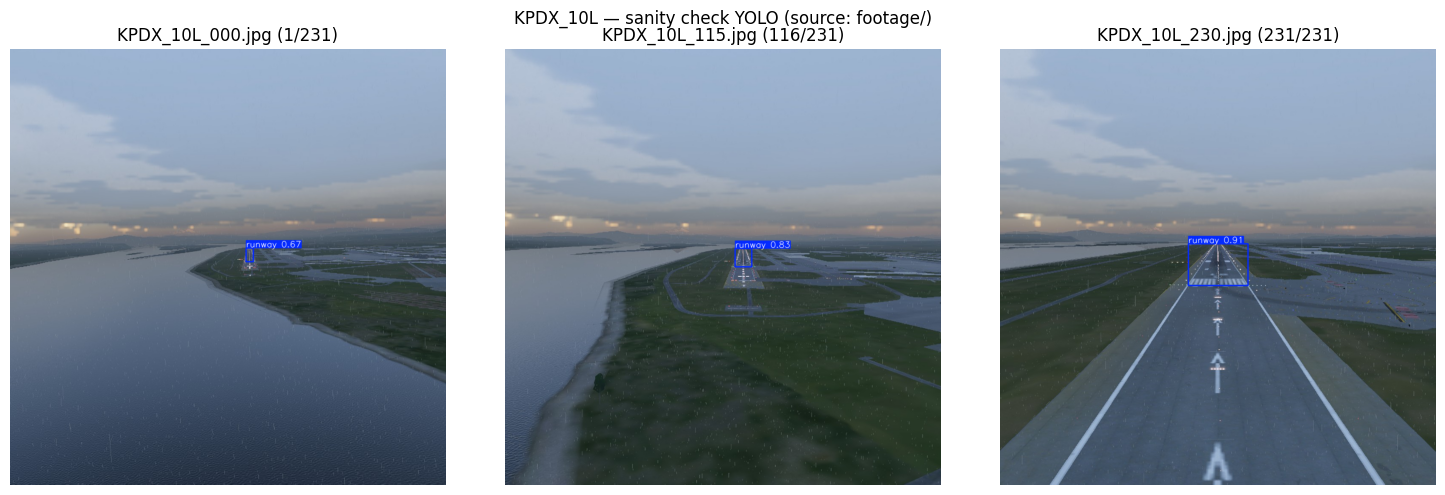

In [8]:
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

def show_sanity(run_name: str | None = None,
                line_width: int = 2, conf: float = 0.25, imgsz: int = 512):
    """Affiche premiere / milieu / derniere image avec bbox YOLO via result.plot()."""
    targets = find_runs(run_name=run_name, all_runs=run_name is None)
    if not targets:
        print("[!] aucun run trouve")
        return
    run = targets[0]

    src = pick_image_source(run)
    images = list_images(src)
    if not images:
        print(f"[!] pas d'images dans {src}")
        return

    n = len(images)
    picks = [(images[0], 0), (images[n // 2], n // 2), (images[-1], n - 1)]

    model = YOLO(str(ROOT / "yolo" / "yolov8nTest.pt"))

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (img_path, idx) in zip(axes, picks):
        result = model.predict(source=str(img_path), conf=conf, imgsz=imgsz,
                               verbose=False)[0]
        annotated = result.plot(line_width=line_width)  # numpy BGR avec bbox
        ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{img_path.name} ({idx + 1}/{n})")
        ax.axis("off")
    fig.suptitle(f"{run.name} — sanity check YOLO (source: {src.name}/)")
    plt.tight_layout()
    plt.show()

show_sanity()

In [9]:
model = YOLO(str(ROOT / "yolo" / "yolov8nTest.pt"))
print("Classes du modèle :", model.names)

Classes du modèle : {0: 'runway'}


## 9. Generer `lard_box/` (images avec bbox GT LARD dessinées)

Usage : `build_lard_box("LFPO_24")` ou `build_lard_box()` (toutes les runs).

In [10]:
from lard_bridge import annotate_gt

def build_lard_box(run_name: str | None = None):
    """Genere runs/<run>/lard_box/ (bbox GT LARD dessinees) via annotate_gt()."""
    for run in find_runs(run_name=run_name, all_runs=run_name is None):
        out = run / "lard_box"
        if out.exists():
            shutil.rmtree(out)
        annotate_gt(run, out_dir=out, prefix="")
        print(f"  {run.name} -> lard_box/")

build_lard_box()

[SKIP] dataset : pas de .yaml
  [GT-VIS] 231 images annotees dans lard_box/
  KPDX_10L -> lard_box/


## 10. Sanity check : 3 images avec bbox GT LARD 

Affiche première / milieu / dernière image d'un run avec les 4 coins GT LARD
(`degraded/` prio sinon `footage/`).

Usage : `show_sanity_lard("LFPO_24")` ou `show_sanity_lard()` (= premier run).

[SKIP] dataset : pas de .yaml


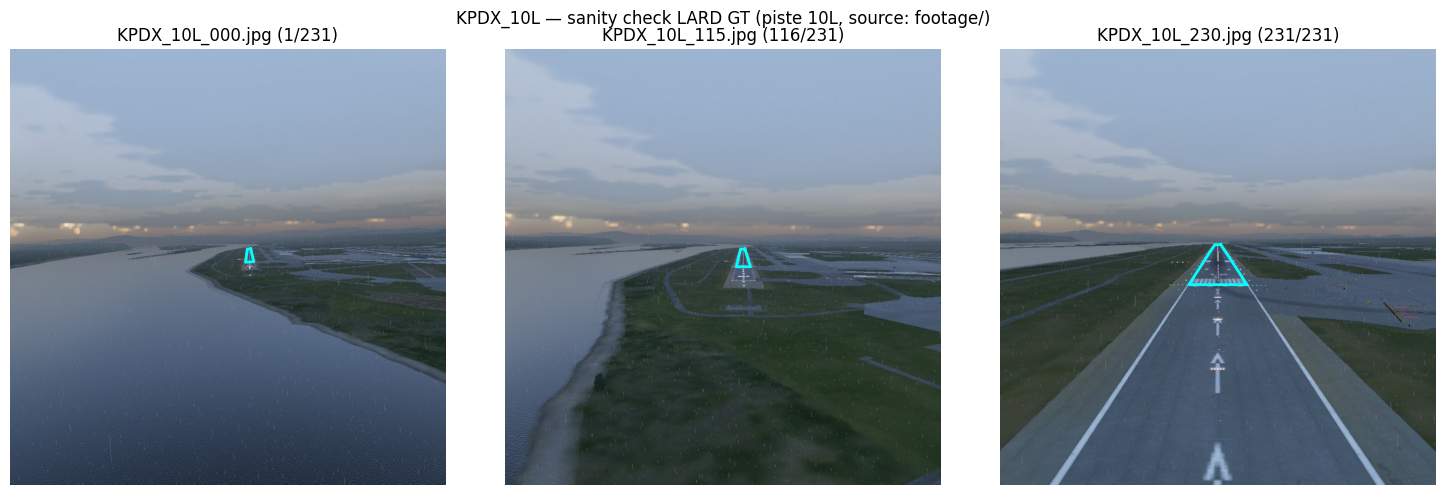

In [11]:
import matplotlib.pyplot as plt
from PIL import Image
from runway import runway_from_run_name
from lard_bridge import load_gt_corners

def show_sanity_lard(run_name: str | None = None, line_width: int = 2):
    """Affiche premiere / milieu / derniere image avec bbox GT LARD (piste cible uniquement)."""
    targets = find_runs(run_name=run_name, all_runs=run_name is None)
    if not targets:
        print("[!] aucun run trouve")
        return
    run = targets[0]

    src = pick_image_source(run)
    images = list_images(src)
    if not images:
        print(f"[!] pas d'images dans {src}")
        return

    target_rwy = runway_from_run_name(run.name)
    csvs = list(run.glob("*_labels.csv"))
    if not csvs:
        print(f"[!] pas de *_labels.csv dans {run}")
        return
    gt = load_gt_corners(csvs[0], runway=target_rwy)

    n = len(images)
    picks = [(images[0], 0), (images[n // 2], n // 2), (images[-1], n - 1)]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (img_path, idx) in zip(axes, picks):
        img = Image.open(img_path)
        ax.imshow(img)
        for corners in gt.get(img_path.name, []):
            xs = [c[0] for c in corners] + [corners[0][0]]
            ys = [c[1] for c in corners] + [corners[0][1]]
            ax.plot(xs, ys, color="cyan", linewidth=line_width)
        ax.set_title(f"{img_path.name} ({idx + 1}/{n})")
        ax.axis("off")
    fig.suptitle(f"{run.name} — sanity check LARD GT (piste {target_rwy}, source: {src.name}/)")
    plt.tight_layout()
    plt.show()

show_sanity_lard()

## 11. Generer `xplane_config.json`

Reconstruit `runs/<run>/xplane_config.json` depuis le yaml (résolution pré-crop, FOV) et
`weather_profile.json` (status). `pilot_eye_*` (dépend de l'avion choisi sur XPLANE12)

Usage : `build_xplane_config("LFPO_24")` ou `build_xplane_config()` (toutes).

In [12]:
import yaml

# Defaults Cessna 172 (vus dans les anciens xplane_config.json)
PILOT_EYE_DEFAULT = {"x": -0.25, "y": 0.40, "z": 0.26}

def build_xplane_config(run_name: str | None = None):
    """Ecrit run_dir/xplane_config.json depuis yaml + weather_profile.json."""
    targets = find_runs(run_name=run_name, all_runs=run_name is None)
    for run in targets:
        yamls = list(run.glob("*.yaml"))
        if not yamls:
            print(f"  [skip] {run.name} : pas de yaml")
            continue
        meta = yaml.safe_load(yamls[0].read_text())
        img = meta.get("image", {})

        weather_status = "absent"
        wp = run / "weather_profile.json"
        if wp.exists():
            weather_status = "ok"

        cfg = {
            "width": int(img.get("width", 1024)),
            "height": int(img.get("height", 1024)),
            "fov_h": float(img.get("fov_x", 60.0)),
            "fov_v": float(img.get("fov_y", 60.0)),
            "pilot_eye_x": PILOT_EYE_DEFAULT["x"],
            "pilot_eye_y": PILOT_EYE_DEFAULT["y"],
            "pilot_eye_z": PILOT_EYE_DEFAULT["z"],
            "weather_status": weather_status,
        }
        out = run / "xplane_config.json"
        with open(out, "w") as f:
            json.dump(cfg, f, indent=2)
        print(f"  {run.name} -> xplane_config.json ({cfg['width']}x{cfg['height']}, weather={weather_status})")

build_xplane_config()

[SKIP] dataset : pas de .yaml
  KPDX_10L -> xplane_config.json (1024x1024, weather=ok)


## 12. Generer `params_trace.xml`

Reconstruit `runs/<run>/params_trace.xml` 

Usage : `build_params_trace("LFPO_24")` ou `build_params_trace()` (toutes).

In [13]:
from xml.etree import ElementTree as ET
from xml.dom import minidom

def _xml_value(parent, tag, value):
    el = ET.SubElement(parent, tag)
    el.text = f"{value}"

def build_params_trace(run_name: str | None = None):
    """Ecrit run_dir/params_trace.xml en agregeant les profils JSON."""
    targets = find_runs(run_name=run_name, all_runs=run_name is None)
    for run in targets:
        poses = json.loads((run / "poses_cam_export.json").read_text()) \
            if (run / "poses_cam_export.json").exists() else {}
        weather = (json.loads((run / "weather_profile.json").read_text()).get("weather", {})
                   if (run / "weather_profile.json").exists() else {})
        faults = (json.loads((run / "fault_profile.json").read_text()).get("faults", [])
                  if (run / "fault_profile.json").exists() else [])

        root = ET.Element("test_case")
        scenario = ET.SubElement(root, "scenario", instance="0/0")

        traj = ET.SubElement(scenario, "trajectory", instance="0/0")
        if "fps" in poses:
            _xml_value(traj, "fps", poses["fps"])
        for k, v in poses.get("trajectory", {}).items():
            _xml_value(traj, k, v)

        wn = ET.SubElement(scenario, "weather", instance="0/0")
        for k, v in weather.items():
            _xml_value(wn, k, v)

        fn = ET.SubElement(scenario, "faults", instance="0/0")
        for f in faults:
            ftype = f.get("fault_type", "unknown")
            sub = ET.SubElement(fn, ftype, instance="0/0")
            for k, v in f.items():
                if k == "fault_type":
                    continue
                _xml_value(sub, k, v)

        xml_str = minidom.parseString(ET.tostring(root)).toprettyxml(indent="  ")
        (run / "params_trace.xml").write_text(xml_str, encoding="utf-8")
        print(f"  {run.name} -> params_trace.xml")

build_params_trace()

[SKIP] dataset : pas de .yaml
  KPDX_10L -> params_trace.xml


## 13. Générer une video MP4 du run/des runs

Concatene les images du run (`degraded/` prio sinon `footage/`) en un MP4 (fps .xml)

Usage :
- `build_video("LFPO_24")` : une seule run
- `build_video()`           : toutes les runs
- `build_video(source="footage")` : force la source (`footage` ou `degraded`)

In [14]:
import cv2

def build_video(run_name: str | None = None, source: str | None = None):
    """Genere runs/<run>/<run>.mp4 (fps depuis poses_cam_export.json).

    source : 'degraded' ou 'footage' (defaut: degraded prio sinon footage).
    """
    targets = find_runs(run_name=run_name, all_runs=run_name is None)
    for run in targets:
        src = (run / source) if source else pick_image_source(run)
        images = list_images(src)
        if not images:
            print(f"  [skip] {run.name} : pas d'images dans {src.name}/")
            continue

        fps = 10
        poses_file = run / "poses_cam_export.json"
        if poses_file.exists():
            fps = int(json.loads(poses_file.read_text()).get("fps", 10))

        first = cv2.imread(str(images[0]))
        if first is None:
            print(f"  [skip] {run.name} : impossible de lire {images[0].name}")
            continue
        h, w = first.shape[:2]

        out = run / f"{run.name}.mp4"
        writer = cv2.VideoWriter(str(out), cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
        for img_path in images:
            img = cv2.imread(str(img_path))
            if img is not None:
                writer.write(img)
        writer.release()

        print(f"  {run.name} -> {out.name}  ({len(images)} frames @ {fps}fps, {src.name}/)")

build_video()

[SKIP] dataset : pas de .yaml
  KPDX_10L -> KPDX_10L.mp4  (231 frames @ 10fps, footage/)
